In [ ]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

In [ ]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold
from sklearn import metrics as _m
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
## load internal (in-house) + public-augmented data, champion model, eval helpers
from copy import deepcopy
from itertools import combinations


# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from python.harmonize_sol import harmonize_solubility

from get_library import get_df   # CDD Vault collection export
from get_protocol_data import get_data, load_config, alias_map
# from tdc.multi_pred import DTI

import yaml
from python.ADME_build_ML import PARAMS, DATA   # CLI classes reused here (%autoreload picks up edits)
from IPython.display import HTML, display



# FUNCTIONS

In [23]:
# per-endpoint classification sign (favorable/positive class) + modelling-space transform used on the raw cutoff
_EP_SIGN = {'solubility': '>=', 'logd': '<', 'hlm': '<', 'mlm': '<', 'rlm': '<', 'caco2': '>=', 'mdck': '>=', 'ppb': '<'}
_EP_TF   = {'solubility': 'log10', 'logd': 'identity', 'hlm': 'log10', 'mlm': 'log10', 'rlm': 'log10', 'caco2': 'log10', 'mdck': 'log10', 'ppb': 'logit_pct'}
# regression columns: table label -> key in each <exp>_metrics dict (from ML_Reg.get_reg_metrics_from_preddf)
_REG_COLS = {'R2_det': 'r2det', 'R2_pears': 'r2', 'RMSE': 'rmse', 'N': 'n_test', 'n_train': 'n_train'}
_CLS_COLS = ['Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC']
_COLS = list(_REG_COLS) + _CLS_COLS
_HIGHER = {'R2_det', 'R2_pears', 'Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC'}; _LOWER = {'RMSE'}   # N / n_train unscored

def _to_model(raw, tf):   # raw-unit cutoff -> modelling space (pred_df is in modelling space)
    if tf == 'log10':     return np.log10(raw)
    if tf == 'logit_pct': return np.log10(raw / (100.0 - raw))
    return raw

def _classif_metrics(pdf, ctf, sign):   # binary triage metrics from a pred_df at the cutoff
    d = pdf.dropna(subset=['real_y', 'pred_y']); yo = d['real_y'].to_numpy(float); yp = d['pred_y'].to_numpy(float)
    rc, pc = (yo < ctf, yp < ctf) if sign == '<' else (yo >= ctf, yp >= ctf)
    return {'Accuracy': _m.accuracy_score(rc, pc), 'PPV': _m.precision_score(rc, pc, zero_division=0),
            'NPV': _m.precision_score(~rc, ~pc, zero_division=0), 'F1(+)': _m.f1_score(rc, pc, zero_division=0),
            'F1(-)': _m.f1_score(rc, pc, pos_label=False, zero_division=0),
            'MCC': _m.matthews_corrcoef(rc, pc) if (rc.min() != rc.max() and pc.min() != pc.max()) else np.nan}

def endpoint_metrics_table_from_dict(metrics_dict, endpoint):
    """HTML table for one endpoint: <exp>_metrics (regression) + <exp>_preddf (classification @ CUTOFFS[endpoint]).

    One row per experiment (the *_preddf entries are used, not shown as rows). CV rows first, temporal rows
    (key contains 'temp') after a double rule. Best per column = bold cyan, worst = orange, WITHIN each
    category. Returns the numeric DataFrame.
    """
    # cutoff in modelling space + favorable-class sign for this endpoint
    ctf = _to_model(CUTOFFS[endpoint], _EP_TF[endpoint]); sign = _EP_SIGN[endpoint]
    # one row per experiment: regression from <exp>_metrics, classification from <exp>_preddf
    exps = [k[:-len('_metrics')] for k in metrics_dict if k.endswith('_metrics')]
    rows = {}
    for e in exps:
        reg = metrics_dict.get(e + '_metrics', {})
        row = {col: reg.get(src) for col, src in _REG_COLS.items()}
        pdf = metrics_dict.get(e + '_preddf')
        if pdf is not None:
            row.update(_classif_metrics(pdf, ctf, sign))
        rows[e] = row
    df = pd.DataFrame(rows).T.reindex(columns=_COLS).apply(pd.to_numeric, errors='coerce')
    # category: CV (0) vs temporal (1); sort category first, then R2det descending within
    df['_ci'] = [1 if 'temp' in k.lower() else 0 for k in df.index]
    df = df.sort_values(['_ci', 'R2_det'], ascending=[True, False]); ci = df['_ci'].to_numpy()
    # best/worst per scored column, WITHIN each category
    def _bw(sub):
        b, w = {}, {}
        for c in _COLS:
            if c in _HIGHER:  b[c], w[c] = sub[c].max(), sub[c].min()
            elif c in _LOWER: b[c], w[c] = sub[c].min(), sub[c].max()
        return b, w
    bws = {c: _bw(df[df['_ci'] == c]) for c in set(ci)}
    CY, OR = '#0097A7', '#F57C00'
    def _fmt(c, v):
        if c in ('N', 'n_train'): return 'nan' if pd.isna(v) else f'{int(v)}'
        return 'nan' if pd.isna(v) else f'{v:.3g}'
    def _td(c, v, bw, sep=''):
        best, worst = bw; s = _fmt(c, v); base = f'text-align:right;padding:2px 8px{sep}'
        if c in best and not pd.isna(v):
            if v == best[c]:                          return f'<td style="color:{CY};font-weight:700;{base}">{s}</td>'
            if v == worst[c] and worst[c] != best[c]: return f'<td style="color:{OR};{base}">{s}</td>'
        return f'<td style="{base}">{s}</td>'
    # header + body (double rule between CV and temporal)
    th = ''.join(f'<th style="text-align:right;padding:2px 8px;border-bottom:1px solid #999">{c}</th>' for c in _COLS)
    body = ''
    for i, (k, r) in enumerate(df.iterrows()):
        sep = ';border-top:3px double #666' if (i > 0 and ci[i] != ci[i - 1]) else ''
        body += (f'<tr><td style="text-align:left;font-weight:600;padding:2px 8px{sep}">{k}</td>' +
                 ''.join(_td(c, r[c], bws[ci[i]], sep) for c in _COLS) + '</tr>')
    cap = (f'<b>{endpoint}</b> — regression + classification @ cutoff {CUTOFFS[endpoint]:g} (sign {sign}) · '
           f'<span style="color:{CY};font-weight:700">best</span>/<span style="color:{OR}">worst</span> per column, '
           f'within each category (double rule = CV / temporal boundary)')
    display(HTML(f'<div style="font:13px sans-serif"><p>{cap}</p><table style="border-collapse:collapse">'
                 f'<thead><tr><th style="text-align:left;padding:2px 8px;border-bottom:1px solid #999">pred_df</th>{th}</tr></thead>'
                 f'<tbody>{body}</tbody></table></div>'))
    return df[_COLS]


def transfer(combo):
    tr = pub.compound[pub.origin.isin(combo)].tolist()
    _, pr = ML_Reg.K_fold_by_defined_IDs(d, 'compound', [[tr, internal.compound.tolist()]], model=model,
                                         col_to_rm=['compound', 'smiles', 'label', 'source', 'origin', '_ik'], v=False)
    y, p = pr.real_y.values, pr.pred_y.values
    return {'combo': '+'.join(o.split(':')[-1] for o in combo), 'n_train': len(tr),
            'R2_pears': np.corrcoef(y, p)[0, 1] ** 2, 'R2_det': 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum(),
            'RMSE': (((y - p) ** 2).mean()) ** 0.5}

def predict_and_record(d, result_df, exp_name='default', ids=None, col_to_rm=None, model=None):
    _ , result_df[exp_name + '_preddf'] = ML_Reg.K_fold_by_defined_IDs(d, 'compound', ids, model=model,col_to_rm=col_to_rm, v=False, uq=True)
    result_df[exp_name + '_metrics'] = ML_Reg.get_reg_metrics_from_preddf(result_df[exp_name + '_preddf'], ntrain=d.shape[0])

    # assign absolute residual + confidence from the RF tree-variance uncertainty
    result_df[exp_name + '_preddf']['residuals'] = abs(result_df[exp_name + '_preddf']['pred_y'] - result_df[exp_name + '_preddf']['real_y'])
    result_df[exp_name + '_preddf'] = ML_Reg.uq_std_to_confidence(result_df[exp_name + '_preddf'])

    return result_df

# MAIN

In [ ]:
## params — every YAML key becomes an attribute (params.ADME_ENDPOINTS); see python/ADME_build_ML.py:PARAMS
CONFIG = 'config/config.yaml'
params = PARAMS(CONFIG)
params.load_params()
## transition shim — keep the bare YAML names (ADME_ENDPOINTS, CUTOFFS, SERAC_C, RF_SINGLETASK, ...) working below
globals().update({k: v for k, v in params.__dict__.items() if k.isupper()})
config = params

In [ ]:
CUTOFFS = {  # raw units; sign in comment. Conventions, not hard rules — see caveats
  'solubility': 10,    # µM,        >= soluble
  'logd':       3,     # logD7.4,   <= within sweet-spot upper bound (>3 = too lipophilic)
  'caco2':      10,    # 1e-6 cm/s, >= high permeability (fa~0.8-0.9)
  'mdck':       10,    # 1e-6 cm/s, >= high permeability
  'ppb':        1,     # % unbound, <= 1  => highly bound (fu<=0.01)
  'hlm':        12,    # µL/min/mg, < 12  => low clearance/stable  (WEAK: measurement floor, no verified triage cutoff)
  'mlm':        12,    # µL/min/mg, same caveat (mouse)
  'rlm':        12,    # µL/min/mg, same caveat (rat)
}

## model params
cfg = yaml.safe_load(open('config/config.yaml'))['RF_SINGLETASK']
model = RandomForestRegressor(**cfg['champion'], n_jobs=cfg['n_jobs'], random_state=cfg['seed'])

## 0. Imports and data formatting

In [ ]:
metrics_results = {}

In [ ]:
## data — internal experimental CDD pull (see python/ADME_build_ML.py:DATA); overwrite=True re-pulls from CDD Vault + re-caches
data = DATA()
data.load_df_internal_exp_all(params)


## 1. Solubility

#### 1.0 featurization

In [26]:
k        = 'solubility'
## solubility augmented dataset — internal thermodynamic + sanitized public EXP (see python/ADME_build_ML.py:DATA.get_solubility_data)
## builds  data.dfs['solubility']   # aggregated solubility data: compound, smiles, label (log10 µM), source, origin, raw (µM)
data.get_solubility_data(params)
# data.dfs['solubility'].head(1)

## H237 molecular features for solubility (see python/ADME_build_ML.py:DATA.build_MF_features_solubility)
## builds  data.MF_features['solubility']   # compound + H237 features (H236 fingerprints/physchem/MACCS/AtomPair + 200 DS_ descriptors)
data.build_MF_features_solubility(type='H237', path=params.MF_features_solubility_f)
data.MF_features[k].head(1)

## solubility modelling frame — H237 features + label (see python/ADME_build_ML.py:DATA.build_ML_data_solubility)
## builds  data.ML_data['solubility']   # features + label (log10 µM, clipped 15000 µM) + compound/smiles/source/origin
data.build_ML_data_solubility()
stats_tools.check_ML_data(data.ML_data[k], extra_meta_cols=('source', 'origin'))

> solubility augmented: 17998 rows (internal=121, EXP=17877)
> MF features (H237): 18024 compounds x 4469 features
> ML_data['solubility']: 17997 rows x 4474 cols (cap 15000 µM, min 0 µM
  [PASS] shape: 17997 rows x 4474 cols
  [PASS] no duplicate 'compound'
  [PASS] no duplicate SMILES
  [PASS] task auto-detected: regression
  [PASS] label is continuous: n_unique=12496, range=[-11.5, 4.18], mean=2.12, std=1.57
  [PASS] 4469 feature columns, all numeric
  [PASS] no NaN in features
  [PASS] no +/-inf in features
  [WARN] 25 constant (zero-variance) feature columns

PASS (0 failure(s))


True

#### 1.1. Prediction

##### 1.1.1. Random Forest

###### 1.1.1.1 Cross validation

In [27]:
## dataset formatting
d        = data.ML_data[k].assign(_ik=[Chem.MolToInchiKey(m) if (m := Chem.MolFromSmiles(s)) else None for s in data.ML_data[k].smiles])
internal = d[d.source == 'internal']
pub      = d[(d.source == 'EXP') & ~d._ik.isin(set(internal._ik.dropna()))]              # drop internal-twin leaks
origins  = pub.origin.value_counts().loc[lambda s: s > 1000].index.tolist()

## run combinatorial analysis to check with public data combinations are the best predictive
# res_origin_powerset = (pd.DataFrame(transfer(c) for k in range(1, len(origins) + 1) for c in combinations(origins, k)).sort_values('R2_pears', ascending=False).reset_index(drop=True))
# display(res_origin_powerset.round(3))

In [28]:
## select best combo and update
combo    = [o for o in origins if o.split(':')[-1] in ['Biogen-Fang']]

pub_ids  = pub.compound[pub.origin.isin(combo)].tolist() #_> [PUB....]
int_ids  = internal.compound.to_numpy()
fold_ids = [[list(int_ids[tr]), list(int_ids[te])] for tr, te in KFold(5, shuffle=True, random_state=42).split(int_ids)]
fold_ids_aug = [[tr + pub_ids, te] for tr, te in fold_ids] # reuse the internal folds; public added to TRAIN only, never test
# temporal:
srb      = internal.compound.str.extract(r'(\d+)')[0].astype(float).to_numpy()
order    = internal.compound.to_numpy()[np.argsort(srb)]
cut      = int(len(order) * 0.8)
train_temp_ids, test_temp_ids = list(order[:cut]), list(order[cut:])

In [29]:
## run predictions 
metrics_results[k]      = {}
col2rm                  = ['compound', 'smiles', 'label', 'source', 'origin', '_ik']
metrics_results[k] = predict_and_record(d, metrics_results[k], 'ext_->_internal', [[pub_ids, int_ids]] , col2rm , model ) # external -> internal
metrics_results[k] = predict_and_record(internal, metrics_results[k], 'internal_cv', fold_ids , col2rm , model ) # internal cv
metrics_results[k] = predict_and_record(d, metrics_results[k], 'augmented_cv', fold_ids_aug , col2rm , model ) # augmented cv
metrics_results[k] = predict_and_record(d, metrics_results[k], 'internal_temp', [[train_temp_ids, test_temp_ids]] , col2rm , model ) # temporal internal
metrics_results[k] = predict_and_record(d, metrics_results[k], 'augmented_temp', [[train_temp_ids + pub_ids, test_temp_ids]] , col2rm , model ) # temporal augmented 
metrics_results[k] = predict_and_record(d, metrics_results[k], 'ext_->_temp', [[pub_ids, test_temp_ids]] , col2rm , model ) # transfer on hold out test set
logd_summary = endpoint_metrics_table_from_dict(metrics_results[k], k)


100%|██████████| 1/1 [00:01<00:00,  1.50s/it]


>>> RMSE: 0.939, R²: 0.58, R²det: 0.373


100%|██████████| 5/5 [00:04<00:00,  1.24it/s]


>>> RMSE: 0.673, R²: 0.679, R²det: 0.677


100%|██████████| 5/5 [00:08<00:00,  1.61s/it]


...

100%|██████████| 1/1 [00:01<00:00,  1.65s/it]


>>> RMSE: 0.568, R²: 0.009, R²det: -1.037


100%|██████████| 1/1 [00:01<00:00,  1.60s/it]

>>> RMSE: 0.703, R²: 0.02, R²det: -2.121


pred_df,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv,0.677,0.679,0.673,120,120,0.85,0.738,0.91,0.775,0.887,0.665
augmented_cv,0.645,0.722,0.706,120,17997,0.85,0.75,0.9,0.769,0.889,0.659
ext_->_internal,0.373,0.58,0.939,120,17997,0.75,0.595,0.833,0.625,0.812,0.439
augmented_temp,-1.04,0.009,0.568,24,17997,0.833,0,0.909,0,0.909,-0.0909
ext_->_temp,-2.12,0.02,0.703,24,17997,0.792,0.2,0.947,0.286,0.878,0.217
internal_temp,-2.4,0.014,0.734,24,17997,0.708,0,0.895,0,0.829,-0.155


> parity: n=24
  value: R²pears=0.009 R²det=-1.037 RMSE=0.568


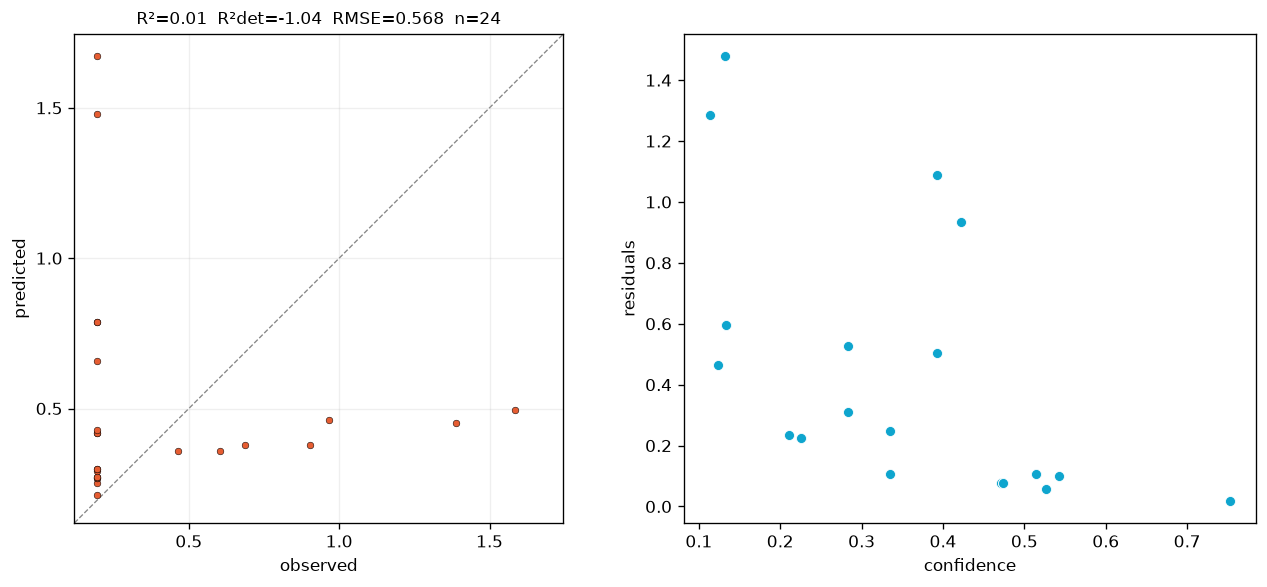

In [31]:
# left: parity for confident predictions (confidence > 0.45); right: confidence vs absolute residual
to_plot = 'augmented_temp'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=120)
_ = ML_Reg.plot_parity_from_pred_df(metrics_results[k][to_plot+'_preddf'], color=SERAC_C['ember'], ax=ax1)
sns.scatterplot(x='confidence', y='residuals', data=metrics_results[k][to_plot+'_preddf'], color=SERAC_C['azure'], ax=ax2)
plt.tight_layout(); plt.show()

In [ ]:
## winner combo: train champion RF on Biogen-Fang (leak-free public), predict internal (raw µM, clipped 20k)

train_ids = pub.compound[pub.origin.isin(combo)].tolist()
test_ids = internal.compound.tolist()

rf_solubility, pred_sol_transfer = ML_Reg.K_fold_by_defined_IDs(
    d, 'compound', [[train_ids, test_ids]], model=model,
    col_to_rm=['compound', 'smiles', 'label', 'source', 'origin', '_ik'], v=True)


In [ ]:
## internal-only 5-fold CV on DEFINED ID folds (fold_ids reused below so the augmented arm shares identical internal test folds)
# 5 random folds over the internal compound ids (fixed seed; reused by the augmented arm for a fair comparison)
int_ids = internal.compound.to_numpy()
fold_ids = [[list(int_ids[tr]), list(int_ids[te])] for tr, te in KFold(5, shuffle=True, random_state=42).split(int_ids)]
rm = ['compound', 'smiles', 'label', 'source', 'origin', '_ik']

# squared-Pearson (R²pears) + coefficient-of-determination (R²det) for a (true, pred) pair
def cv_metrics(yv, pv):
    return np.corrcoef(yv, pv)[0, 1] ** 2, 1 - ((yv - pv) ** 2).sum() / ((yv - yv.mean()) ** 2).sum()

# out-of-fold predictions on internal only (champion RF, H237 features)
_, pred_sol_cv = ML_Reg.K_fold_by_defined_IDs(internal, 'compound', fold_ids, model=model, col_to_rm=rm, v=False)

# parity in raw µM (log axes) + both-space metrics + 15 µM triage cross
ML_Reg.plot_parity_from_pred_df(pred_sol_cv, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                         title=f'internal-only temporal (n_train={len(train_temp_ids)})')

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
_ = ML_Class.classification_from_regression_pred(pred_sol_cv, np.log10(15), sign='>=')


In [ ]:
## augmented 5-fold CV: each internal train fold + Biogen-Fang public (leak-free); SAME internal test folds -> isolates the augmentation gain
# leak-free Biogen-Fang public compound ids
aug_ids = pub.compound[pub.origin.str.contains('Biogen-Fang')].tolist()
# modelling frame = internal rows + the Biogen-Fang rows only
d_aug = d[(d.source == 'internal') | d.compound.isin(aug_ids)]
# reuse the internal folds; public added to TRAIN only, never test
fold_ids_aug = [[tr + aug_ids, te] for tr, te in fold_ids]
# out-of-fold predictions with the augmented training set
_, pred_sol_aug_cv = ML_Reg.K_fold_by_defined_IDs(d_aug, 'compound', fold_ids_aug, model=model, col_to_rm=rm, v=False)

# parity in raw µM (log axes) + both-space metrics + 15 µM triage cross
ML_Reg.plot_parity_from_pred_df(pred_sol_aug_cv, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                         title=f'internal-only temporal (n_train={len(train_temp_ids)})')

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
_ = ML_Class.classification_from_regression_pred(pred_sol_aug_cv, np.log10(15), sign='>=')


###### 1.1.1.2 Temporal test split

In [ ]:
## temporal test internal only — train oldest 80% internal (by SRB id), predict newest 20% internal
# order internal compounds by SRB id (oldest -> newest)
srb = internal.compound.str.extract(r'(\d+)')[0].astype(float).to_numpy()
order = internal.compound.to_numpy()[np.argsort(srb)]
# split: oldest 80% train, newest 20% test
cut = int(len(order) * 0.8)
train_temp_ids, test_temp_ids = list(order[:cut]), list(order[cut:])
# single-fold temporal predictions (internal only)
_, pred_sol_temp = ML_Reg.K_fold_by_defined_IDs(internal, 'compound', [[train_temp_ids, test_temp_ids]], model=model, col_to_rm=rm, v=False)

# parity in raw µM (log axes) + both-space metrics + 15 µM triage cross
m_temp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                         title=f'internal-only temporal (n_train={len(train_temp_ids)})')
# keep the internal-only temporal baseline (log10, raw) for the augmented / external / chemprop arms
tlog, traw = m_temp['orig'], m_temp['raw']

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
_ = ML_Class.classification_from_regression_pred(pred_sol_temp, np.log10(15), sign='>=')

In [ ]:
## temporal test augmented + internal — same temporal test, add Biogen-Fang public to the internal training fold
# single-fold temporal predictions with internal-train + Biogen-Fang public
rf_sol_temp_aug, pred_sol_temp_aug = ML_Reg.K_fold_by_defined_IDs(d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], model=model, col_to_rm=rm, v=False,uq=True)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_aug = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_aug, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                        title=f'internal+Biogen temporal (n_aug={len(aug_ids)})')
# augmentation gain vs the internal-only temporal baseline
print(f"  gain vs internal-only  log10: Δpears {m_aug['orig'][0]-tlog[0]:+.3f} Δdet {m_aug['orig'][1]-tlog[1]:+.3f}   raw µM: Δpears {m_aug['raw'][0]-traw[0]:+.3f} Δdet {m_aug['raw'][1]-traw[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
_ = ML_Class.classification_from_regression_pred(pred_sol_temp_aug, np.log10(15), sign='>=')

In [ ]:
pred_sol_temp_aug['residuals'] = abs(pred_sol_temp_aug['pred_y'] - pred_sol_temp_aug['real_y'])
sns.scatterplot(x='uq_std', y='residuals',data=pred_sol_temp_aug)

In [ ]:
## temporal test external only — train on Biogen-Fang public ONLY (no internal), predict the temporal hold-out
# single-fold: train = leak-free Biogen-Fang public, test = the newest-internal temporal hold-out (no internal in train)
_, pred_sol_temp_ext = ML_Reg.K_fold_by_defined_IDs(d_aug, 'compound', [[aug_ids, test_temp_ids]], model=model, col_to_rm=rm, v=False)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_ext = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_ext, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                        title=f'external-only temporal (n_train={len(aug_ids)})')
# gain vs the internal-only temporal baseline
print(f"  gain vs internal-only  log10: Δpears {m_ext['orig'][0]-tlog[0]:+.3f} Δdet {m_ext['orig'][1]-tlog[1]:+.3f}   raw µM: Δpears {m_ext['raw'][0]-traw[0]:+.3f} Δdet {m_ext['raw'][1]-traw[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_ext, np.log10(15), sign='>=')

##### 1.1.2. Chemprop

In [ ]:
## chemprop on train_temp_ids + aug_ids -> test_temp_ids: HPO-best D-MPNN, temporal augmented
# chemprop v2 executable + the HPO-best config (output/chemprop_hpo_best.json: depth 3 / hidden 2400 / ffn 2x300 / dropout 0 / agg sum / bs 64; R²pears 0.671 > RF 0.599 on Biogen-Fang -> internal)
CHEMPROP_BIN = os.path.expanduser('~/miniconda3/envs/chemprop/bin/chemprop')
cp_best = {'depth': 3, 'message_hidden_dim': 2400, 'ffn_num_layers': 2, 'ffn_hidden_dim': 300, 'dropout': 0.0, 'aggregation': 'sum', 'batch_size': 64}
# precomputed H237 descriptastorus (DS_) columns -> reused by chemprop via --descriptors-columns (no native recompute)
ds_cols = [c for c in d_aug.columns if c.startswith('DS_')]
# train D-MPNN on internal-temporal-train + Biogen-Fang public, predict the temporal hold-out
pred_sol_temp_cp = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_best, task_type='regression', uncertainty='none',
    descriptor_cols=ds_cols, epochs=50, v=True)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_cp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_cp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                       title='chemprop internal+Biogen temporal (HPO-best)')
# gain vs the internal-only RF temporal baseline
print(f"  vs internal-only RF  log10: Δpears {m_cp['orig'][0]-tlog[0]:+.3f} Δdet {m_cp['orig'][1]-tlog[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_cp, np.log10(15), sign='>=')

In [ ]:
## chemprop on internal train + aug_ids: temporal augmented D-MPNN (fast hand-picked HP, evidential-epistemic uncertainty)
# chemprop v2 executable + the FAST hand-picked config (wiki 2026-07-22: depth 3 / hidden 300 / ffn 2x300 / dropout 0.146 / agg sum; deployed depth-6 is the heavy one)
CHEMPROP_BIN = os.path.expanduser('~/miniconda3/envs/chemprop/bin/chemprop')
cp_hp, cp_epochs = params.TEMPORAL_FRACTIONS['chemprop_hp'], params.TEMPORAL_FRACTIONS['chemprop_epochs']
# precomputed H237 descriptastorus (DS_) columns -> reused by chemprop via --descriptors-columns (no native recompute)
ds_cols = [c for c in d_aug.columns if c.startswith('DS_')]
# train D-MPNN on internal-temporal-train + Biogen-Fang public, predict the temporal hold-out
pred_sol_temp_cp = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[aug_ids , int_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression-evidential', uncertainty='evidential-epistemic',
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)

# parity in raw µM + both-space metrics + 15 µM triage cross
m_cp = ML_Reg.plot_parity_from_pred_df(pred_sol_temp_cp, transform='log10', abline=15, unit='µM', color=SERAC_C['ember'],
                                       title='chemprop internal+Biogen temporal')
# gain vs the internal-only RF temporal baseline
print(f"  vs internal-only RF  log10: Δpears {m_cp['orig'][0]-tlog[0]:+.3f} Δdet {m_cp['orig'][1]-tlog[1]:+.3f}")

# triage classification at the 15 µM solubility cutoff
print("\nclassification from regression @ 15 µM (soluble = >= 15):")
ML_Class.classification_from_regression_pred(pred_sol_temp_cp, np.log10(15), sign='>=')

In [ ]:
## chemprop MC-dropout UQ — plain-regression D-MPNN (fast HP), 30 dropout passes, same temporal split
# train a plain-regression D-MPNN (dropout kept on at inference), predict the temporal hold-out with MC-dropout
pred_sol_temp_cp_drop = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression', uncertainty='dropout', dropout_sampling_size=30,
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)
# UQ vs residual — positive Spearman = uncertainty tracks error (useful for triage)
u = pred_sol_temp_cp_drop['uncertainty'].to_numpy(); r = (pred_sol_temp_cp_drop.real_y - pred_sol_temp_cp_drop.pred_y).abs().to_numpy()
rs = stats.spearmanr(u, r)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(u, r, s=22, c=SERAC_C['olive'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop MC-dropout uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — MC-dropout UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(r)}')
sns.despine(); plt.tight_layout(); plt.show()


In [ ]:
## chemprop ensemble UQ — 5-model ensemble (fast HP), across-member variance, same temporal split
# train a 5-model ensemble, predict the temporal hold-out with ensemble-variance uncertainty
pred_sol_temp_cp_ens = ML_Reg.chemprop_K_fold_by_defined_IDs(
    d_aug, 'compound', [[train_temp_ids + aug_ids, test_temp_ids]], CHEMPROP_BIN, target='label',
    hp=cp_hp, task_type='regression', uncertainty='ensemble', ensemble_size=5,
    descriptor_cols=ds_cols, epochs=cp_epochs, v=False)
# UQ vs residual — positive Spearman = uncertainty tracks error (useful for triage)
u = pred_sol_temp_cp_ens['uncertainty'].to_numpy(); r = (pred_sol_temp_cp_ens.real_y - pred_sol_temp_cp_ens.pred_y).abs().to_numpy()
rs = stats.spearmanr(u, r)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(u, r, s=22, c=SERAC_C['gold'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop 5-model ensemble uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — ensemble UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(r)}')
sns.despine(); plt.tight_layout(); plt.show()


#### 1.2. Uncertainty quantification

In [ ]:
## why are the temporal compounds hard? — mean top-k NN Tanimoto distance (test -> augmented train) vs prediction residual
# Morgan ECFP4 bit columns (F0..) from H237, keyed by compound — the binary MF for Tanimoto
_fcols = [c for c in data.MF_features['solubility'].columns if c[:1] == 'F' and c[1:].isdigit()]
mfbits = data.MF_features['solubility'][['compound'] + _fcols]
train_ids = train_temp_ids + aug_ids
k = 5
# pairwise Tanimoto distance (test x augmented-train), then the k nearest train neighbours per test compound (rdkit_tools)
dist = rdkit_tools.get_RDKiTTanimoto_distance_matrix(mfbits[mfbits.compound.isin(test_temp_ids)], mfbits[mfbits.compound.isin(train_ids)])
nnk = rdkit_tools.get_NN_from_dist_matrix(dist, top=k)
# per test compound: mean top-k distance (novelty) + the single nearest neighbour (for source colouring)
agg = nnk.groupby('compound').agg(distance=('distance', 'mean'), NN=('NN', 'first'))
# join novelty onto |residual| (log10) and tag the nearest neighbour's source (internal vs Biogen-Fang)
src = d_aug.set_index('compound')['source']
ad = (pred_sol_temp_aug.assign(resid=(pred_sol_temp_aug.real_y - pred_sol_temp_aug.pred_y).abs())
      .set_index('compound').join(agg))
ad['nn_src'] = src.reindex(ad['NN']).values
# rank correlation between novelty and error
rs = stats.spearmanr(ad['distance'], ad['resid'])
# scatter: novelty (x) vs error (y), coloured by nearest-neighbour source
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
for s_, col in [('internal', SERAC_C['ember']), ('EXP', SERAC_C['azure'])]:
    m = ad['nn_src'] == s_
    ax.scatter(ad.loc[m, 'distance'], ad.loc[m, 'resid'], s=22, c=col, alpha=0.7, edgecolors='none', label=f'NN in {s_} (n={int(m.sum())})')
ax.set(xlabel=f'mean top-{k} NN Tanimoto distance to augmented train', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — novelty vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(ad)}')
ax.legend(fontsize=8); sns.despine()
plt.tight_layout(); plt.show()


In [ ]:
## epistemic uncertainty via RF tree variance — same temporal augmented model: std of per-tree predictions vs |residual|
# test feature matrix, rows aligned to the prediction order (drop the meta columns the RF never saw)
sub = d_aug[d_aug.compound.isin(test_temp_ids)].set_index('compound')
feat = [c for c in sub.columns if c not in ('smiles', 'label', 'source', 'origin', '_ik')]
Xte = sub.loc[pred_sol_temp_aug.compound, feat].to_numpy()
# per-tree predictions -> std across trees = epistemic (model-disagreement) uncertainty
tree_preds = np.stack([t.predict(Xte) for t in rf_sol_temp_aug.estimators_])
rf_std = tree_preds.std(axis=0)
resid = (pred_sol_temp_aug.real_y - pred_sol_temp_aug.pred_y).abs().to_numpy()
# rank correlation between RF variance and error
rs = stats.spearmanr(rf_std, resid)
# scatter: epistemic uncertainty (x) vs error (y)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(rf_std, resid, s=22, c=SERAC_C['azure'], alpha=0.7, edgecolors='none')
ax.set(xlabel='RF tree-prediction std  (epistemic uncertainty, log10 µM)', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — RF variance vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(resid)}')
sns.despine(); plt.tight_layout(); plt.show()


In [ ]:
## chemprop evidential-epistemic uncertainty vs residual — same temporal augmented model
# evidential-epistemic uncertainty and |residual| (log10) per temporal-test compound
unc = pred_sol_temp_cp['uncertainty'].to_numpy()
resid = (pred_sol_temp_cp.real_y - pred_sol_temp_cp.pred_y).abs().to_numpy()
# rank correlation between evidential uncertainty and error
rs = stats.spearmanr(unc, resid)
# scatter: epistemic uncertainty (x) vs error (y)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=120)
ax.scatter(unc, resid, s=22, c=SERAC_C['azure'], alpha=0.7, edgecolors='none')
ax.set(xlabel='chemprop evidential-epistemic uncertainty', ylabel='|residual|  (log10 µM)',
       title=f'temporal test — chemprop evidential UQ vs error\nSpearman r={rs.statistic:.2f} (p={rs.pvalue:.2g}), n={len(resid)}')
sns.despine(); plt.tight_layout(); plt.show()


## 2. LogD

#### 2.0 featurization

In [18]:
metrics_results['logd'] = {}

In [19]:
## logD augmented dataset — internal LogD7.4 + sanitized public EXP (see python/ADME_build_ML.py:DATA.get_logd_data)
## builds  data.dfs['logd']   # aggregated logD data: compound, smiles, label (logD7.4, identity), source, origin, raw (logD7.4)
data.get_logd_data(params)
# data.dfs['logd'].head(1)

## H237 molecular features for logD (see python/ADME_build_ML.py:DATA.build_MF_features_logd)
## builds  data.MF_features['logd']   # compound + H237 features (H236 fingerprints/physchem/MACCS/AtomPair + 200 DS_ descriptors)
data.build_MF_features_logd(type='H237', path=params.MF_features_logd_f)
data.MF_features['logd'].head(1)

## logD modelling frame — H237 features + label (see python/ADME_build_ML.py:DATA.build_ML_data_logd)
## builds  data.ML_data['logd']   # features + label (logD7.4, no cap) + compound/smiles/source/origin
data.build_ML_data_logd()
stats_tools.check_ML_data(data.ML_data['logd'], extra_meta_cols=('source', 'origin'))
data.dfs['logd'].origin.unique()

> logd augmented: 4518 rows (internal=318, EXP=4200)
> MF features (H237): 4518 compounds x 4469 features
> ML_data['logd']: 4516 rows x 4474 cols
  [PASS] shape: 4516 rows x 4474 cols
  [PASS] no duplicate 'compound'
  [PASS] no duplicate SMILES
  [PASS] task auto-detected: regression
  [PASS] label is continuous: n_unique=601, range=[-1.5, 5.73], mean=2.23, std=1.21
  [PASS] 4469 feature columns, all numeric
  [PASS] no NaN in features
  [PASS] no +/-inf in features
  [WARN] 109 constant (zero-variance) feature columns

PASS (0 failure(s))


array(['internal', 'TDC:Lipophilicity_AstraZeneca'], dtype=object)

#### 2.1. Prediction

In [20]:
## dataset formatting
d        = data.ML_data['logd'].assign(_ik=[Chem.MolToInchiKey(m) if (m := Chem.MolFromSmiles(s)) else None for s in data.ML_data['logd'].smiles])
internal = d[d.source == 'internal']
pub      = d[(d.source == 'EXP') & ~d._ik.isin(set(internal._ik.dropna()))]              # drop internal-twin leaks
origins  = pub.origin.value_counts().loc[lambda s: s > 1000].index.tolist()
pub_ids  = pub.compound.tolist() #_> [PUB....]
int_ids  = internal.compound.to_numpy()
fold_ids = [[list(int_ids[tr]), list(int_ids[te])] for tr, te in KFold(5, shuffle=True, random_state=42).split(int_ids)]
fold_ids_aug = [[tr + pub_ids, te] for tr, te in fold_ids] # reuse the internal folds; public added to TRAIN only, never test
# temporal:
srb      = internal.compound.str.extract(r'(\d+)')[0].astype(float).to_numpy()
order    = internal.compound.to_numpy()[np.argsort(srb)]
cut      = int(len(order) * 0.8)
train_temp_ids, test_temp_ids = list(order[:cut]), list(order[cut:])

In [ ]:
## run predictions 
col2rm                  = ['compound', 'smiles', 'label', 'source', 'origin', '_ik']
metrics_results['logd'] = predict_and_record(d, metrics_results['logd'], 'ext_->_internal', [[pub_ids, int_ids]] , col2rm , model ) # external -> internal
metrics_results['logd'] = predict_and_record(internal, metrics_results['logd'], 'internal_cv', fold_ids , col2rm , model ) # internal cv
metrics_results['logd'] = predict_and_record(d, metrics_results['logd'], 'augmented_cv', fold_ids_aug , col2rm , model ) # augmented cv
metrics_results['logd'] = predict_and_record(d, metrics_results['logd'], 'internal_temp', [[train_temp_ids, test_temp_ids]] , col2rm , model ) # temporal internal
metrics_results['logd'] = predict_and_record(d, metrics_results['logd'], 'augmented_temp', [[train_temp_ids + pub_ids, test_temp_ids]] , col2rm , model ) # temporal augmented 
metrics_results['logd'] = predict_and_record(d, metrics_results['logd'], 'ext_->_temp', [[pub_ids, test_temp_ids]] , col2rm , model ) # transfer on hold out test set
logd_summary = endpoint_metrics_table_from_dict(metrics_results['logd'], 'logd')

100%|██████████| 1/1 [00:03<00:00,  3.74s/it]


>>> RMSE: 1.042, R²: 0.607, R²det: 0.249


100%|██████████| 5/5 [00:04<00:00,  1.15it/s]


>>> RMSE: 0.51, R²: 0.822, R²det: 0.82


100%|██████████| 5/5 [00:18<00:00,  3.79s/it]


...

100%|██████████| 1/1 [00:03<00:00,  3.76s/it]


>>> RMSE: 0.83, R²: 0.335, R²det: -0.485


100%|██████████| 1/1 [00:03<00:00,  3.43s/it]

>>> RMSE: 1.435, R²: 0.061, R²det: -3.44


pred_df,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv,0.82,0.822,0.51,317,317,0.871,0.857,0.883,0.866,0.875,0.741
augmented_cv,0.806,0.815,0.53,317,4516,0.864,0.821,0.913,0.865,0.863,0.734
ext_->_internal,0.249,0.607,1.04,317,4516,0.498,0.487,1,0.655,0.0809,0.143
internal_temp,0.297,0.46,0.571,64,4516,0.891,0.5,0.917,0.364,0.94,0.323
augmented_temp,-0.485,0.335,0.83,64,4516,0.828,0.333,0.942,0.421,0.899,0.345
ext_->_temp,-3.44,0.061,1.44,64,4516,0.125,0.111,1,0.2,0.0345,0.0442


> parity: n=317
  value: R²pears=0.815 R²det=0.806 RMSE=0.530


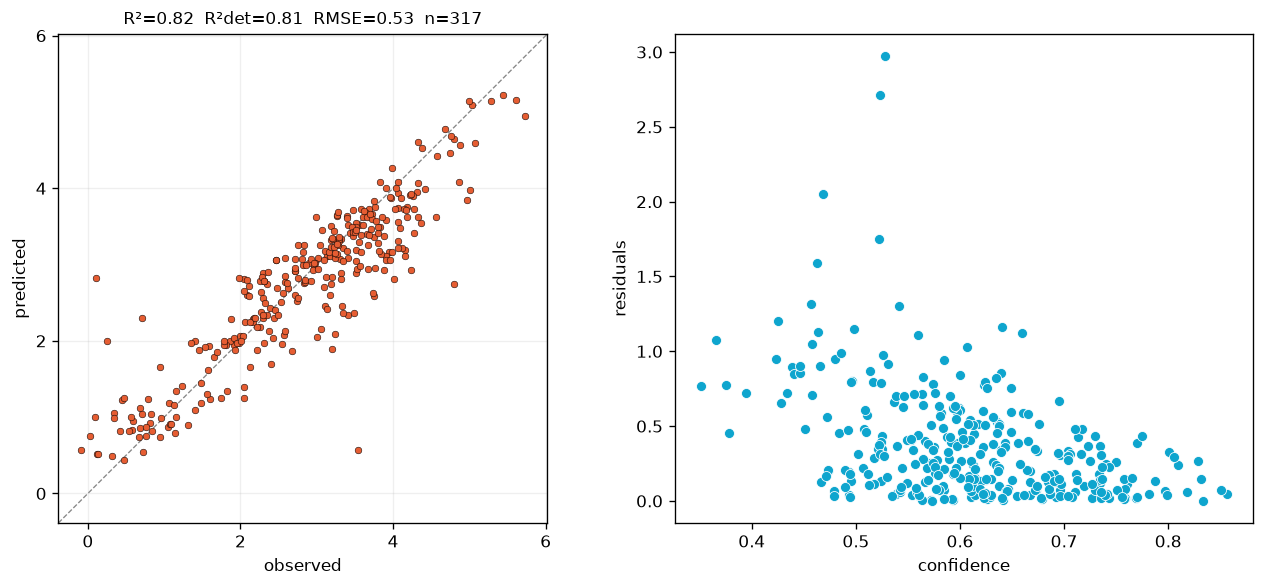

In [ ]:
# left: parity for confident predictions (confidence > 0.45); right: confidence vs absolute residual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=120)
_ = ML_Reg.plot_parity_from_pred_df(metrics_results['logd']['augmented_cv_preddf'], color=SERAC_C['ember'], ax=ax1)
sns.scatterplot(x='confidence', y='residuals', data=metrics_results['logd']['augmented_cv_preddf'], color=SERAC_C['azure'], ax=ax2)
plt.tight_layout(); plt.show()